---


# Contexto para os exercícios:
A loja "GT Auto" decidiu aprimorar os treinamentos de vendedores inexperientes de carros, criando uma base de dados dos veículos disponíveis que apresente algumas informações importantes para treinar os novos vendedores. 
A base de dados foi criada em um documento de texto e contém as seguintes informações:

*   Marca/Modelo/Ano do carro: brand/model/year
*   Capacidade volumétrica (cc) ou volume de deslocamento do motor: cap_vol.
*   Consumo de combustível (km/l): consumo.
*   Potência (cv): power.
*   Peso (kg): weight.
*   0-100 (s), tempo que o carro demora para atingir a velocidade de 100km/h: cemm. 
*   Número de cilindros: nu_cy. 
*   Tipo de motor, aspirado (0) ou turbo (1): Etype.

# Semana 1 - Regressão Linear Simples

Analise os dados dos 14 carros com motor aspirado que a "GT Auto" tem em estoque para venda, e crie alguns gráficos que simplifiquem as informações úteis para ajudar os novos vendedores a entenderem melhor as características dos carros. Seguem algumas sugestões:

a. Realizar um diagrama de ramo e folha para observar as variáveis.

b. Realize um diagrama de dispersão para verificar a correlação entre a capacidade volumetrica e o consumo de combustível.

c. Realize um diagrama de dispersão para verificar a correlação entre a capacidade volumétrica e potência.

d. Realize um diagrama de dispersão para verificar a correlação entre o peso e o tempo 0-100.

Explique como devemos utilizar essas informações nos treinamentos.

## Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importando a fonte de dados

In [2]:
df = pd.read_csv("Fonte_de_dados/Cars_vertical1.txt", sep=",")

## Análise inicial dos dados

In [3]:
print(df.head())

          brand/model/year  cap_vol  consumo  power  weight  cemm  nu_cy  \
0    Gurgel BR800 0.8 1991      792     12.0     33     650  34.4      2   
1   FIAT UNO Mille EP 1996      994     10.4     58     870  18.6      4   
2  Hyundai HB20 Sense 2020     1000     12.8     80     989  14.5      3   
3     FIAT Strada 1.4 2016     1368     10.3     86    1084  12.5      4   
4  VolksWagen GOL 1.6 2015     1598     10.5    104     961   9.8      4   

   Etype  
0      0  
1      0  
2      0  
3      0  
4      0  


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand/model/year  14 non-null     str    
 1   cap_vol           14 non-null     int64  
 2   consumo           14 non-null     float64
 3   power             14 non-null     int64  
 4   weight            14 non-null     int64  
 5   cemm              14 non-null     float64
 6   nu_cy             14 non-null     int64  
 7   Etype             14 non-null     int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 1.3 KB


In [5]:
df.describe()

,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0
mean,2867.785714,8.357143,218.000000,1294.714286,11.007143,5.357143,0.0
std,2066.127935,2.848944,168.564984,348.445654,7.917893,2.590133,0.0
min,792.000000,3.000000,33.000000,650.000000,3.600000,2.000000,0.0
25%,1425.500000,6.525000,90.500000,1012.750000,6.175000,4.000000,0.0
50%,1998.000000,8.850000,151.500000,1320.500000,10.000000,4.000000,0.0
75%,3422.750000,10.375000,296.750000,1572.500000,12.100000,6.000000,0.0
max,7291.000000,12.800000,602.000000,1760.000000,34.400000,12.000000,0.0


## Tratamento dos dados 

In [6]:
c1=df["cap_vol"]
c2=df["consumo"]
c3=df["power"]
c4=df["weight"]
c5=df["cemm"]
c6=df["nu_cy"]

## Resolvendo as questões

In [7]:
# Configuração para gráficos bonitos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### a. Realizar um diagrama de ramo e folha para observar as variáveis.

In [8]:
# Função para gerar stem-and-leaf plot
def stem_leaf_plot(data, title="Stem-and-Leaf Plot"):
    data_sorted = sorted(data)
    stems = [int(x/10) for x in data_sorted]
    leaves = [x % 10 for x in data_sorted]
    
    unique_stems = sorted(set(stems))
    
    print(f"\n{title}")
    print("-" * 30)
    for stem in unique_stems:
        leaves_for_stem = [str(leaves[i]) for i in range(len(stems)) if stems[i] == stem]
        print(f"{stem} | {' '.join(leaves_for_stem)}")


In [9]:
stem_leaf_plot(c1, "cap_vol")


cap_vol
------------------------------
79 | 2
99 | 4
100 | 0
136 | 8
159 | 8
179 | 6
199 | 7 9
299 | 6
319 | 7
349 | 8
546 | 1
616 | 2
729 | 1


In [10]:
stem_leaf_plot(c2, "consumo")


consumo
------------------------------
0 | 3.0 4.2 6.4 6.5 6.6 7.1 8.5 9.2 9.5
1 | 0.3000000000000007 0.40000000000000036 0.5 2.0 2.8000000000000007


In [11]:
stem_leaf_plot(c3, "power")


power
------------------------------
3 | 3
5 | 8
8 | 0 6
10 | 4
14 | 4 8
15 | 5
21 | 8
26 | 9
30 | 6
38 | 8
46 | 1
60 | 2


In [12]:
stem_leaf_plot(c4, "weight")



weight
------------------------------
65 | 0
87 | 0
96 | 1
98 | 9
108 | 4
123 | 0
129 | 4
134 | 7
142 | 7
146 | 0
161 | 0
170 | 9
173 | 5
176 | 0


In [13]:
stem_leaf_plot(c5, "cemm")


cemm
------------------------------
0 | 3.6 4.2 5.4 6.1 6.4 7.1 9.8
1 | 0.1999999999999993 0.40000000000000036 0.9000000000000004 2.5 4.5 8.600000000000001
3 | 4.399999999999999


In [14]:

stem_leaf_plot(c6, "nu_cy")


nu_cy
------------------------------
0 | 2 3 4 4 4 4 4 4 6 6 6 8 8
1 | 2


### b. Realize um diagrama de dispersão para verificar a correlação entre a capacidade volumetrica e o consumo de combustível.

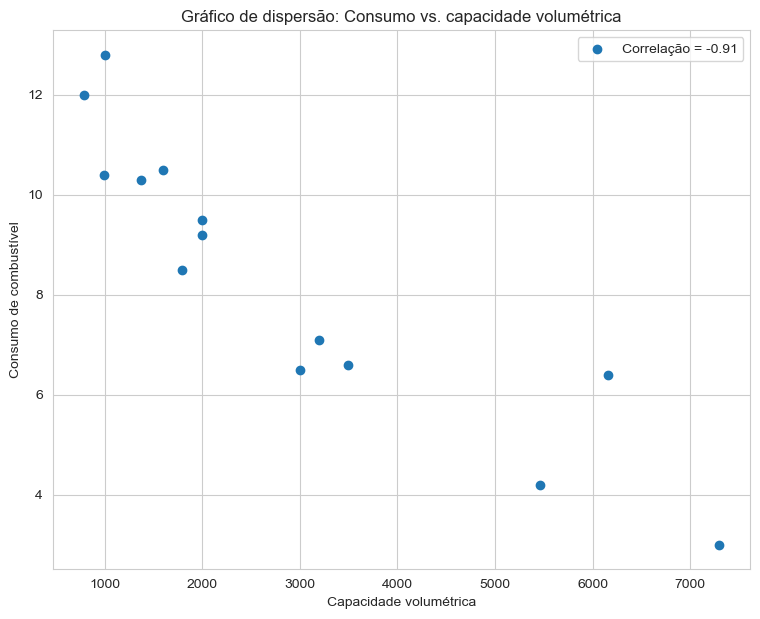

In [15]:
#Consumo vs. capacidade volumétrica --> c1,c2
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':100})
plt.scatter(c1, c2, label=f'Correlação = {np.round(np.corrcoef(c1,c2)[0,1], 2)}')
plt.xlabel('Capacidade volumétrica')
plt.ylabel('Consumo de combustível')
plt.title('Gráfico de dispersão: Consumo vs. capacidade volumétrica')
plt.legend()
plt.grid(True)
plt.show()

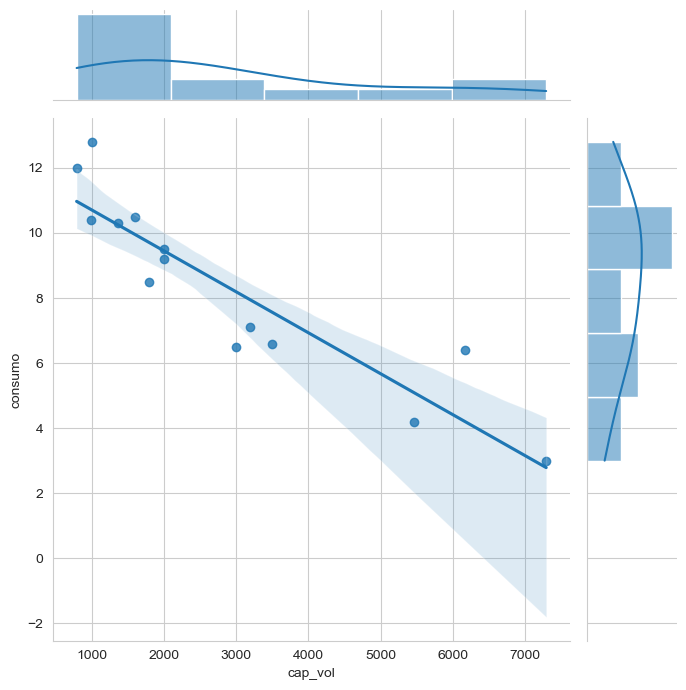

In [16]:
sns.jointplot(x=c1, y=c2, kind="reg", height=7)

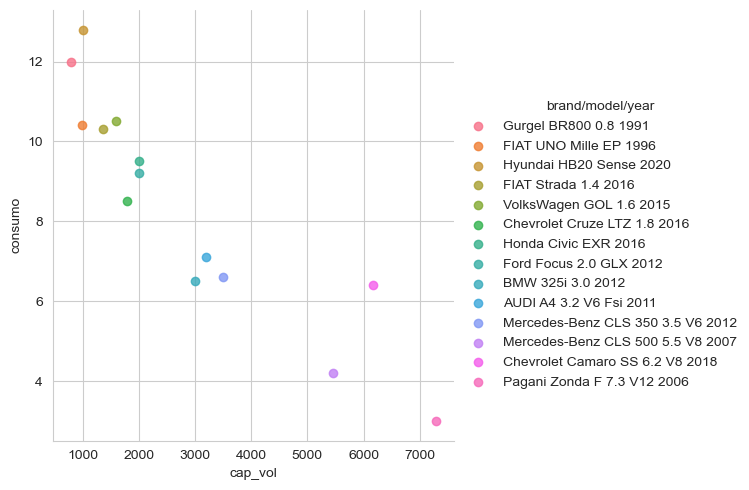

In [17]:
df1 = pd.DataFrame(data=df)
plt.rcParams.update({'figure.figsize':(10,8), 'figure.dpi':100})
sns.lmplot(x='cap_vol', y='consumo', hue='brand/model/year', data=df1);

### c. Realize um diagrama de dispersão para verificar a correlação entre a capacidade volumétrica e potência.



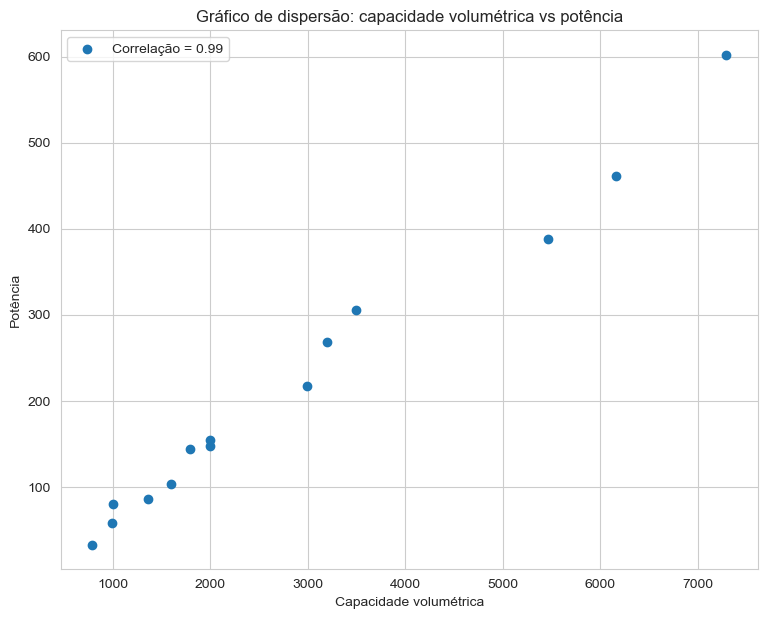

In [18]:
#capacidade volumétrica vs potencia --> c1,c3
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':100})
plt.scatter(c1, c3, label=f'Correlação = {np.round(np.corrcoef(c1,c3)[0,1], 2)}')
plt.xlabel('Capacidade volumétrica')
plt.ylabel('Potência')
plt.title('Gráfico de dispersão: capacidade volumétrica vs potência')
plt.legend()
plt.grid(True)
plt.show()

### d. Realize um diagrama de dispersão para verificar a correlação entre o peso e o tempo 0-100.


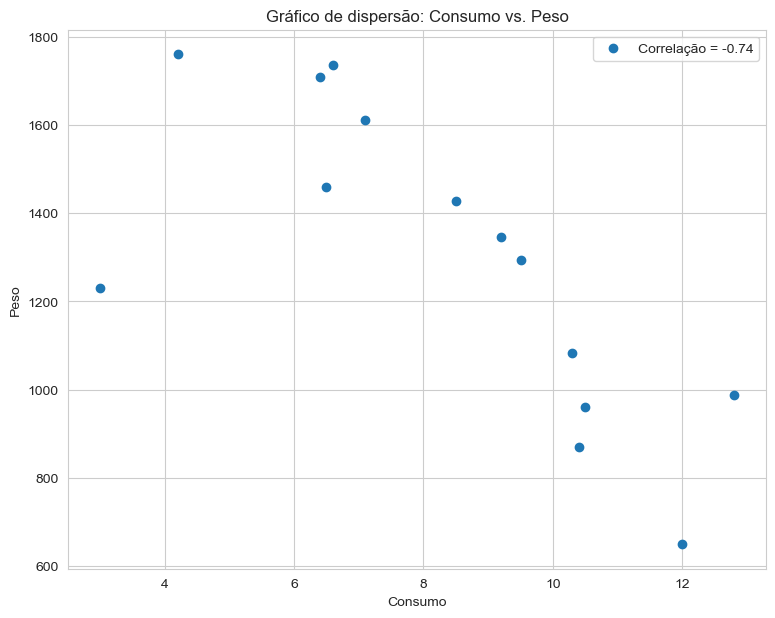

In [19]:
#Outros dados: Consumo vs. Peso--> c2,c4
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':100})
plt.scatter(c2,c4, label=f'Correlação = {np.round(np.corrcoef(c2,c4)[0,1], 2)}')
plt.xlabel('Consumo')
plt.ylabel('Peso')
plt.title('Gráfico de dispersão: Consumo vs. Peso')
plt.legend()
plt.grid(True)
plt.show()

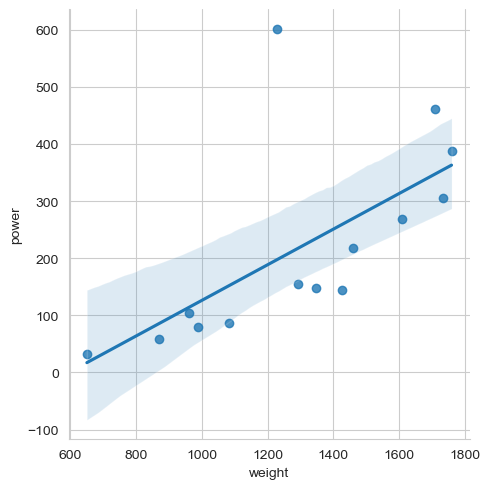

In [20]:
#capcidade número de cilundros vs potência
sns.lmplot(x='weight', y='power', data=df);

# Semana 2 -  Ajustes

Após ter realizado a análise dos dados apresentados, obter as equações da reta de mínimos quadrados para prever o consumo de combustível padrão de acordo com a capacidade volumétrica, e, se necessário, separe os dados de acordo com o tipo de motor.


## Importações

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [83]:
df = pd.read_csv("Fonte_de_dados/PES310_carst.csv")

In [84]:
df.head(30)


,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
0,Gurgel BR800 0.8 1991,792,12.0,33,650,34.4,2,0
1,FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
2,Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
3,FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
4,VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0
5,Chevrolet Cruze LTZ 1.8 2016,1796,8.5,144,1427,10.2,4,0
6,Honda Civic EXR 2016,1997,9.5,155,1294,10.9,4,0
7,Ford Focus 2.0 GLX 2012,1999,9.2,148,1347,10.4,4,0
8,BMW 325i 3.0 2012,2996,6.5,218,1460,7.1,6,0
9,AUDI A4 3.2 V6 Fsi 2011,3197,7.1,269,1610,6.4,6,0


## Tratamento de dados

In [24]:
df1 = pd.DataFrame(data=df)
c0=df1["brand/model/year"]
c1=df1["cap_vol"]
c2=df1["consumo"]
c3=df1["power"]
c4=df1["weight"]
c5=df1["cemm"]
c6=df1["nu_cy"]
c7=df1["Etype"]

## Consumo vs. potência para todos os carros 

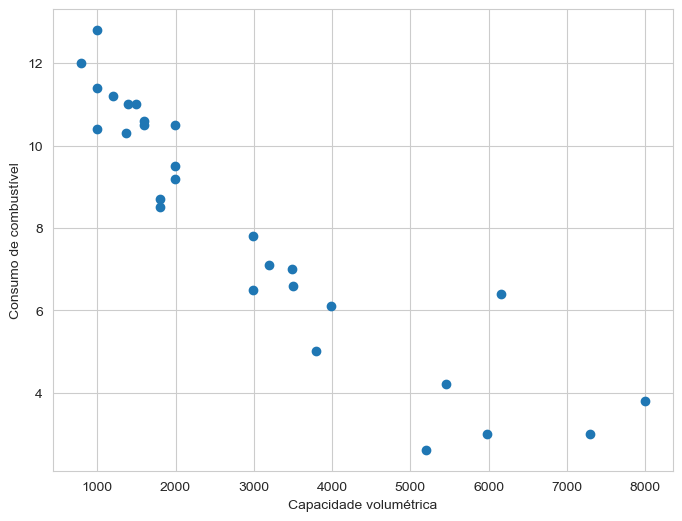

In [25]:
# Consumo vs. potência para todos os carros 
df1 = pd.DataFrame(data=df)
plt.rcParams.update({'figure.figsize':(8,6), 'figure.dpi':100})
plt.scatter(df1['cap_vol'],df1['consumo'])
plt.xlabel('Capacidade volumétrica');
plt.ylabel('Consumo de combustível')
plt.grid(True)
plt.show()

## Obter a equação da reta de mínimos quadrados - Opção 1

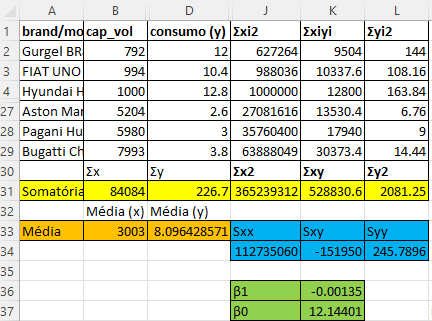

Estimated coefficients:
b_0 = 12.144010117932384            
b_1 = -0.0013478460028317721


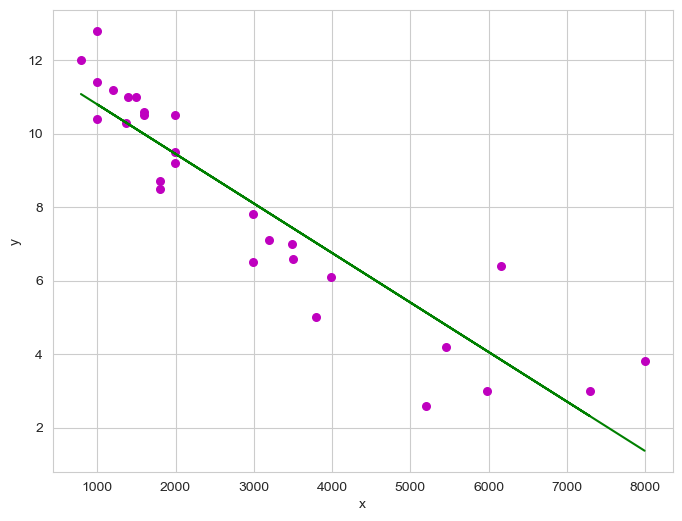

In [26]:
# fonte: Adaptado de https://github.com/OpenGenus/quark/blob/master/code/code/artificial_intelligence/src/Linear_Regression/linear_regression.py
#import numpy as np
#import matplotlib.pyplot as plt
def estimate_coef(x, y):
    # Número de amostras
    n = np.size(x)
 
    # média dos valores x e y
    m_x = np.mean(x)
    m_y = np.mean(y)
 
    # Calculo da relação cruzada e correlação de x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
 
    # Aplicar as fórmulas para obter os parÂmetros beta 0 e beta 1
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1 * m_x
    return (b_0, b_1)

 #criar gráfico para observar o resultado
def plot_regression_line(x, y, b):
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",
               marker = "o", s = 30)
 
    # predicted response vector
    y_pred = b[0] + b[1]*x
 
    # plotting the regression line
    plt.plot(x, y_pred, color = "g")
 
    # putting labels
    plt.xlabel('x')
    plt.ylabel('y')
 
    # function to show plot
    plt.grid(True)
    plt.show()
 
def main():
    # definir os dados (variáveis) x e y
    x= df['cap_vol']  # capacidade volumêtrica, variável preditora
    y= df['consumo'] # consumo, variável resposta  
 
 
    # estimar os coeficientes ou parâmetros
    b = estimate_coef(x, y)
    print("Estimated coefficients:\nb_0 = {}  \
          \nb_1 = {}".format(b[0], b[1]))
 
    # plotar a curva de regressão linear
    plot_regression_line(x, y, b)
 
if __name__ == "__main__":
    main()

### Observar os dados com a reta obtida 

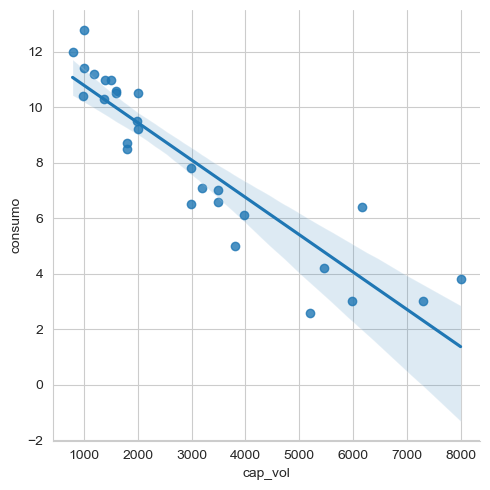

In [27]:
plt.rcParams.update({'figure.figsize':(10,8), 'figure.dpi':100})
sns.lmplot(x='cap_vol', y='consumo', data=df);plt.grid(True)

### Criar duas bases de dados para motor aspirado e motor turbo

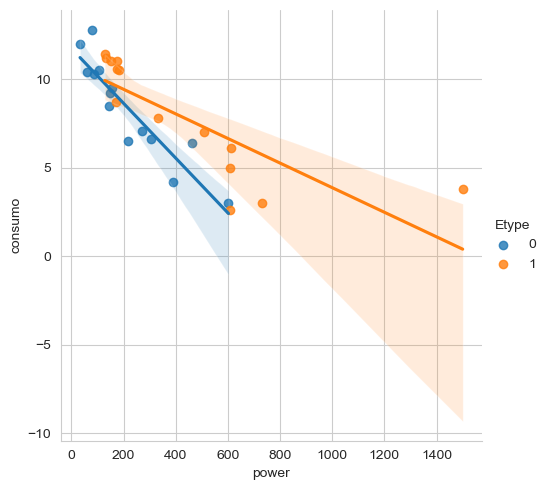

In [28]:
plt.rcParams.update({'figure.figsize':(10,8), 'figure.dpi':100})
sns.lmplot(x='power', y='consumo',hue='Etype', data=df1);plt.grid(True)

### Obter a Equação da reta de regressão para os subconjuntos de dados

### Equação da reta Consumo vs. Potência - Todos os motores
Considerando todos os carros:
$y= \beta_0 + \beta_1 x_1$  

$y= 12,14401  -0.00135 x_1$  



### Equação da reta Consumo vs. Potência - Motor Aspirado
Considerando os carros com motor aspirado:

$y= \beta_0 + \beta_1 x_1$  

$y= 11.72962 - 0.0012593 x_1$  



### Equação da reta Consumo vs. Potência  - Motor Turbo
Considerando os carros com motor turbo:

$y= \beta_0 + \beta_1 x_1$  

$y= 12.320915 -0.001429x_1$  


## Obter a equação da reta de mínimos quadrados - Opção 2
$y= \beta_0 + \beta_1 x_1$  

In [29]:
#usando numpy
y = c2
#definir a vriável preditora
x = c1
z = np.polyfit(x,y,1)
print('y= {0} {1}x'.format(z[1],z[0]))

y= 12.144010117932384 -0.0013478460028317726x


## Obter a equação da reta de mínimos quadrados - Opção 3
$y= \beta_0 + \beta_1 x_1$  

In [30]:
#usando statsmodels.api
#https://www.statology.org/sst-ssr-sse-in-python/
import statsmodels.api as sm
#definir a variável resposta
y = df1['consumo']
#definir a variável preditora
x = df1[['cap_vol']]
#adicionar uma constante preditora
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit() #atenção esta variável será usada no IC
print(modelo.summary())
# mais infomrações https://www.statsmodels.org/stable/index.html


                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     129.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.30e-11
Time:                        20:15:22   Log-Likelihood:                -45.064
No. Observations:                  28   AIC:                             94.13
Df Residuals:                      26   BIC:                             96.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1440      0.427     28.435      0.0

In [31]:
import statsmodels.api as sm
dfmo = pd.DataFrame(modelo.summary().tables[1].data)
# Select first row as column names:
dfmo.columns = dfmo.iloc[0, :]
# Select first column as row names
dfmo.index = dfmo.iloc[:, 0]
# Remove the first (i.e. 0th) column and first row
dfmo = dfmo.iloc[1:, 1:]
# Print relevant info only
print(dfmo.iloc[:,[0, 1, 4, 5]])

0              coef    std err     [0.025     0.975]
                                                    
const       12.1440      0.427     11.266     13.022
cap_vol     -0.0013      0.000     -0.002     -0.001


### Calcular os valores esperados de Y
$\hat{y}_i=\hat{\beta_0} + \hat{\beta_1} x_i$ 

In [32]:
#obter os valores esperados de y
#$\hat{y}_i=\hat{\beta_0} + \hat{\beta_1} x_i$ 
ychapeu= modelo.fittedvalues
ychapeu
dfy = pd.DataFrame(data=ychapeu)
dfy

,0
0,11.076516
1,10.804251
2,10.796164
3,10.300157
4,9.990152
5,9.723279
6,9.452362
7,9.449666
8,8.105863
9,7.834946


### Calcular os resíduos

In [33]:
#resíduos
res=ychapeu-c2
res

0    -0.923484
1     0.404251
2    -2.003836
3     0.000157
4    -0.509848
5     1.223279
6    -0.047638
7     0.249666
8     1.605863
9     0.734946
10    0.829245
11    0.583423
12   -2.561417
13   -0.683135
14   -0.602488
15   -0.672057
16   -0.741626
17   -0.875063
18   -0.609848
19    1.020583
20   -1.048986
21    0.307211
22    0.435984
23    2.023543
24    0.676887
25    2.529820
26    1.083891
27   -2.429323
dtype: float64

### Calcular o quadrado do resíduo

In [34]:
# Quadrado dos resíduos
res2=res**2
res2

0     8.528225e-01
1     1.634190e-01
2     4.015358e+00
3     2.458187e-08
4     2.599448e-01
5     1.496411e+00
6     2.269412e-03
7     6.233309e-02
8     2.578798e+00
9     5.401463e-01
10    6.876469e-01
11    3.403825e-01
12    6.560857e+00
13    4.666735e-01
14    3.629918e-01
15    4.516609e-01
16    5.500098e-01
17    7.657356e-01
18    3.719143e-01
19    1.041590e+00
20    1.100372e+00
21    9.437881e-02
22    1.900821e-01
23    4.094727e+00
24    4.581765e-01
25    6.399987e+00
26    1.174820e+00
27    5.901610e+00
dtype: float64

### Observar os valores em tabela

In [35]:
%pip install tabulate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:

from tabulate import tabulate


In [72]:
dfy.columns = ['y_chapeu']
res.columns = ['residuos']  
res2.columns = ['residuos_quadrados']

In [73]:
df_yo = pd.DataFrame(c2).T
df_ych = pd.DataFrame(dfy).T
df_ycho = pd.DataFrame(res).T
df_ycho2 = pd.DataFrame(res2).T

In [76]:
# Concatenar horizontalmente
df_completo = pd.concat([df_yo, df_ych, df_ycho, df_ycho2], axis=1)
print(tabulate(df_completo, headers='keys', tablefmt='grid'))

+----------+-----+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------+-------+-------+------+------+-------+-------+-------+-------+------+------+-------+-------+------+-------+----------+----------+----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+----------+----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+------------+------------+-----------+---------------+------------+-----------+-------------+------------+-----------+------------+------------+------------+-----------+------------+------------+------------+------------+------------+------------+-----------+-----------+------------+------------+-----------+------------+-----------+-----------+-----------+------------+------------+-----------+---------------+------------+-----------+-------

### Calcular SQE e SQT Alternativa 1
Adaptado de https://www.statology.org/sst-ssr-sse-in-python/

In [87]:
#calcular SQE--> Baseado nos valores esperados
sqe = np.sum((ychapeu - df.consumo)**2)
print("SQE=", sqe)

#calcular SQT-->Baseado nos valores observados
sqt = np.sum((c2 - df.consumo.mean())**2)
print("SQT=", sqt)

#calcular SQR
sqr = sqt - sqe
print("SQR=",sqr)

SQE= 40.98511664985651
SQT= 245.78964285714284
SQR= 204.80452620728633


### Calcular o coeficiente de determinação $r^2$

In [88]:
r2=1-sqe/sqt
print("coeficiente de determinação=",r2, "ou",r2*100, "%")

coeficiente de determinação= 0.8332512461736324 ou 83.32512461736324 %


### Calcular variância estimada $s^2$ e devio padrão estimado $s$

In [89]:
# variância estimada $s^2$ e desvio padrão estimado $s^2$
s2=sqe/(len(c2)-2)
s=pow(s2,1/2)
print('variância estimada= {0}, desvio padrão estimado= {1}'.format(s2,s))

variância estimada= 1.5763506403790966, desvio padrão estimado= 1.2555280324943352


Na sequência observe uma nova alternativa para calcular as variáveis $S_{xx},S_{xy},S_{yy}$ e o coeficiente de correlação (como plus) em uma única função.

In [90]:
#O seguinte código pode também ser usado previamente para calcular SQE, SQT, SQR e r2 (Alternativa 2)
# fonte: Adaptado de https://www.geeksforgeeks.org/sum-function-python/
def linreg(X, Y):
    """
    retorna a solução b0 e b1 para a reta y = b0 + b1x e todas as somatórias necessárias
    """
    N = len(X)
    Sx = Sy = Sxx = Syy = Sxy = 0.0
    for x, y in zip(X, Y):
        Sx = Sx + x           # Somatória do termos x
        Sy = Sy + y           # Somatória do termos y
        Sxx = Sxx + x*x       # Somatória do termos x^2
        Syy = Syy + y*y       # Somatória do termos y^2
        Sxy = Sxy + x*y       # Somatória do termos x vezes y
    det = Sxx * N - Sx * Sx   # variável auxiliar
    Sxxt= Sxx - Sx*Sx/N       # Termo Sxx
    Sxyt= Sxy - Sx*Sy/N       # Termo Sxy  
    Syyt= Syy - Sy*Sy/N       # Termo Syy  
    r=Sxyt/pow((Sxxt*Syyt), 1/2)
    return (Sxy * N - Sy * Sx)/det, (Sxx * Sy - Sx * Sxy)/det, Sx, Sy, Sxx,  Syy , Sxy, Sxxt, Sxyt, Syyt,r


In [91]:
#Mostrar os resultados
b1,b0,sox,soy,sox2,soy2,soxy,sxx,sxy,syy,corr = linreg(df1['cap_vol'],df1['consumo'])  #
print('b0= {0},b1= {1}'.format(b0,b1))
print('Somatória x= {0}, Somatória y= {1},Somatória xy= {2}'.format(sox,soy,soxy))
print('Somatória x^2= {0}, Somatória y^2= {1}'.format(sox2,soy2))
print('Sxx= {0}, Syy {1}, Sxy {2}'.format(sxx,syy,sxy))
print('r= {0}'.format(corr))

b0= 12.14401011793238,b1= -0.0013478460028317728
Somatória x= 84084.0, Somatória y= 226.7,Somatória xy= 528830.6
Somatória x^2= 365239312.0, Somatória y^2= 2081.25
Sxx= 112735060.0, Syy 245.78964285714324, Sxy -151949.5
r= -0.912825967078956


Observe que o coeficiente de correlação $r=-0.91$
Observe que o coeficiente de determinação $r^2=0.8325$

## SQE e SQT Alternativa 2
Visto que os valores de Sxx, Syy e Sxy estão disponíveis, pode se também usar a simples susbtituição nas respectivas fórmulas de SQE e SQT

In [92]:
#SQE e SQT Alternativa 2
sqe=syy-b1*sxy
sqt=syy
sqr=sqt-sqe
sqe,sqt,sqr
print('SQE= {0}, SQT {1}, SQR {2}'.format(sqe,sqt,sqr))

SQE= 40.985116649856764, SQT 245.78964285714324, SQR 204.80452620728647


#Verificar o intervalo de confiança de $\beta_1$

Considerando a reta obtida dos dados de todos os motores $y= 12,14401  -0.00135 x_1$.

Para finalizar, calcular o **erro padrão de ${\beta_1}$** com a seguinte equação

$s_{\hat{\beta_1}}=\frac{s}{\sqrt{S_{xx}}}$


In [93]:
ebeta=s/pow(sxx,1/2)
ebeta

np.float64(0.00011824884667786773)

### Probabilidade t-student e intervalo de confiança 

In [94]:
import statsmodels.api as sm
# Automatic calculation
lm_fit = modelo#sm.OLS(y, x_mat).fit()
# dir(lm_fit)
# Get the summary table with coefficients and other statistics
df = pd.DataFrame(lm_fit.summary().tables[1].data)
# Select first row as column names:
df.columns = df.iloc[0, :]
# Select first column as row names
df.index = df.iloc[:, 0]
# Remove the first (i.e. 0th) column and first row
df = df.iloc[1:, 1:]
# Print relevant info only
print(df.iloc[:,[0, 1, 4, 5]])

0              coef    std err     [0.025     0.975]
                                                    
const       12.1440      0.427     11.266     13.022
cap_vol     -0.0013      0.000     -0.002     -0.001


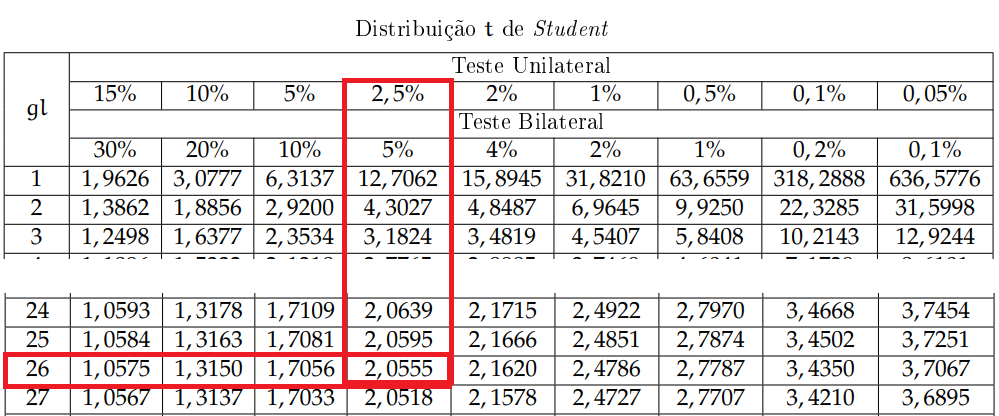

In [95]:
#usar a tabela tstudent t0,025:N-2
from scipy.stats import t
alpha = 0.05  # nÍvel de significia = 5% 
df = len(c2) - 2  # graus de liberdade (Número de amostras menos dois)                                     
#
v = t.ppf(1 - alpha/2, df) 
print(f'v: {v}') 

v: 2.0555294386428735


In [98]:
#Finalmente calcular o IC de b1
ICbeta1= b1+v*ebeta
ICbeta2= b1-v*ebeta
ICbeta2,ICbeta1,b1,v,ebeta
print('O intevalo de confiança é {:.4f} < b1 < {:.4f}'.format(ICbeta2,ICbeta1))

O intevalo de confiança é -0.0016 < b1 < -0.0011


# Semana 4 - Adequação do modelo e modelos não lineares

In [101]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot
plt.style.use('seaborn-v0_8')
plt.rc('axes', titlesize=10)

In [ ]:
#Observar os dados
#import io
#import pandas as pd
df = pd.read_csv('Fonte_de_dados/PES310_S4_carst2.csv')
df.head(30)

,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
0,Gurgel BR800 0.8 1991,792,12.0,33,650,34.4,2,0
1,FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
2,Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
3,FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
4,VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0
5,Chevrolet Cruze LTZ 1.8 2016,1796,8.5,144,1427,10.2,4,0
6,Honda Civic EXR 2016,1997,9.5,155,1294,10.9,4,0
7,Ford Focus 2.0 GLX 2012,1999,9.2,148,1347,10.4,4,0
8,BMW 325i 3.0 2012,2996,6.5,218,1460,7.1,6,0
9,AUDI A4 3.2 V6 Fsi 2011,3197,7.1,269,1610,6.4,6,0


In [110]:
df.columns # há espaços nos nomes das colunas, cuidado!

Index(['brand/model/year', ' cap_vol', ' consumo', ' power', ' weight',
       ' cemm', ' nu_cy', ' Etype'],
      dtype='str')

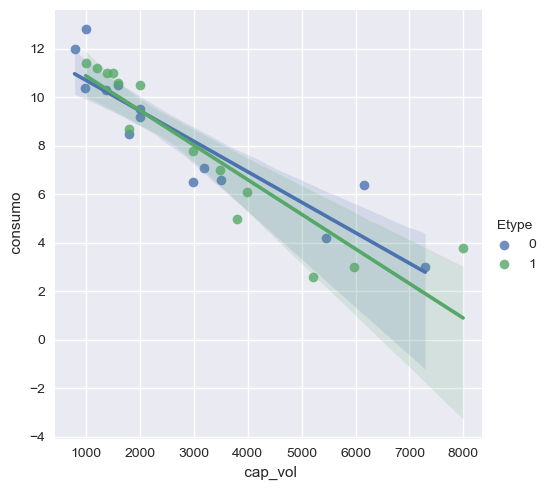

In [111]:
sns.lmplot(x=' cap_vol', y=' consumo',hue=' Etype', data=df);plt.grid(True)

In [113]:
df1 = df[df[' Etype'] != 1]
df1.head(15)

,brand/model/year,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
0,Gurgel BR800 0.8 1991,792,12.0,33,650,34.4,2,0
1,FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
2,Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
3,FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
4,VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0
5,Chevrolet Cruze LTZ 1.8 2016,1796,8.5,144,1427,10.2,4,0
6,Honda Civic EXR 2016,1997,9.5,155,1294,10.9,4,0
7,Ford Focus 2.0 GLX 2012,1999,9.2,148,1347,10.4,4,0
8,BMW 325i 3.0 2012,2996,6.5,218,1460,7.1,6,0
9,AUDI A4 3.2 V6 Fsi 2011,3197,7.1,269,1610,6.4,6,0


In [114]:
df1 = pd.DataFrame(data=df1)
#definir a variável resposta
y = df1[' consumo']
#definir a vriável preditora
x = df1[' cap_vol']

### Gráficos de diagnóstico 1 (y vs. x)

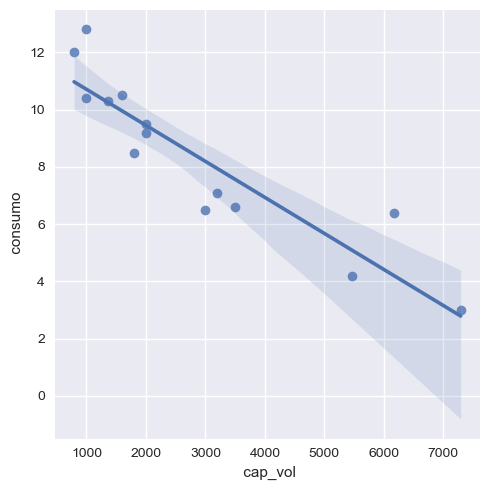

In [115]:
#@title Gráficos de diagnóstico 1 (y vs. x)
sns.lmplot(x=' cap_vol', y=' consumo', data=df1);plt.grid(True)

In [116]:
#adicionar uma constante preditora
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit() #atenção esta variável será usada no IC
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     60.33
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           5.08e-06
Time:                        12:09:05   Log-Likelihood:                -21.429
No. Observations:                  14   AIC:                             46.86
Df Residuals:                      12   BIC:                             48.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.9686      0.566     21.145      0.0

In [120]:
# parâmetros da reta
b=modelo.params
b

const       11.968579
 cap_vol    -0.001259
dtype: float64

In [125]:

b0=b['const'] #intercepto
b1=b[' cap_vol'] #inclinação
print('y= {0}{1} x'.format(b0,b1))

y= 11.968578736702083-0.0012593116220535796 x


In [133]:
x = df1[' cap_vol']

In [134]:
y_pred=list(modelo.predict())
#sns.resid(modelo)
resi=list(modelo.resid)

In [135]:
#crear instancia influence
influence = modelo.get_influence()
#obter residuos standardizados
stdresid = list(influence.resid_studentized_internal)

In [136]:
prop=np.divide(resi,stdresid) #e/e* para verificar a proporcionalidade entre o erro e o erro padronizado

In [137]:
#@title Tabela geral
dft = pd.DataFrame(list(zip(x, y, y_pred, resi, stdresid, prop)),
               columns =["x","y","yc","e","e*","e/e*"])
dft 

,x,y,yc,e,e*,e/e*
0,792,12.0,10.971204,1.028796,0.923383,1.114160
1,994,10.4,10.716823,-0.316823,-0.281988,1.123532
2,1000,12.8,10.709267,2.090733,1.860422,1.123795
3,1368,10.3,10.245840,0.054160,0.047584,1.138197
4,1598,10.5,9.956199,0.543801,0.474716,1.145529
5,1796,8.5,9.706855,-1.206855,-1.048677,1.150836
6,1997,9.5,9.453733,0.046267,0.040048,1.155287
7,1999,9.2,9.451215,-0.251215,-0.217440,1.155327
8,2996,6.5,8.195681,-1.695681,-1.457151,1.163696
9,3197,7.1,7.942559,-0.842559,-0.724684,1.162657


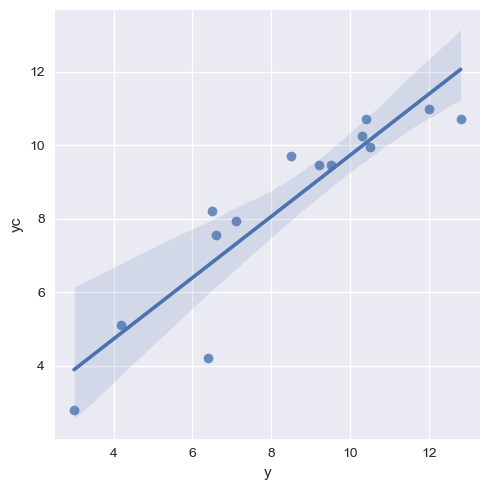

In [138]:
#@title Gráficos de diagnóstico 2 (y vs. yc)
sns.lmplot(x='y', y='yc', data=dft);plt.grid(True)

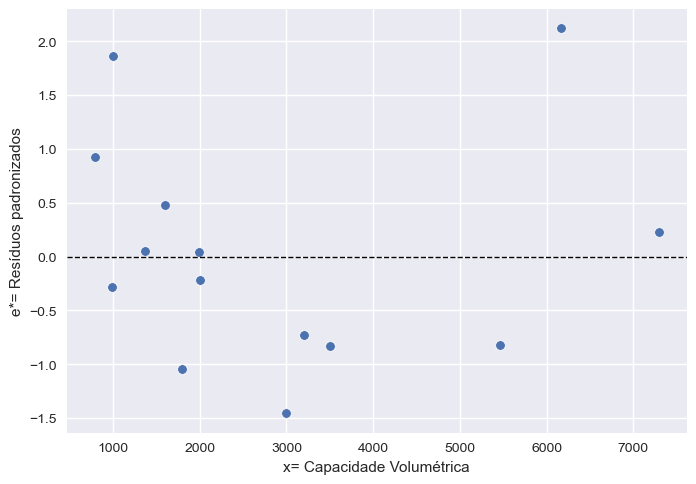

In [139]:
#@title Gráficos de diagnóstico 3 (resíduos padronizados vs. x)
sns.scatterplot(x='x', y='e*', data=dft);plt.grid(True)
plt.xlabel('x= Capacidade Volumétrica')
plt.ylabel('e*= Resíduos padronizados')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

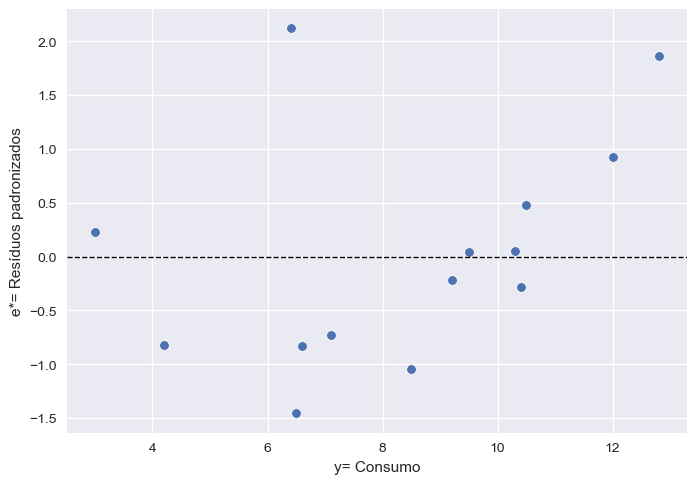

In [140]:
#@title Gráficos de diagnóstico 4 (resíduos padronizados vs. y)
sns.scatterplot(x='y', y='e*', data=dft);plt.grid(True)
plt.xlabel('y= Consumo')
plt.ylabel('e*= Resíduos padronizados')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

Text(0, 0.5, 'Resíduos padronizados')

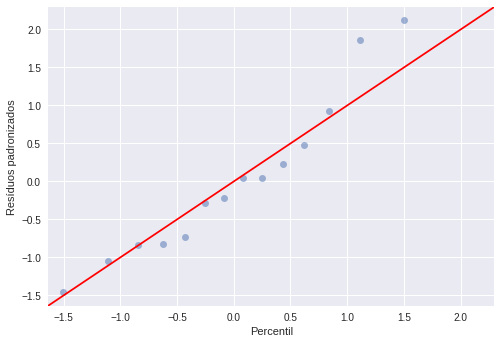

In [ ]:
#@title Gráficos de diagnóstico 5 Probabilidade Normal
QQ = ProbPlot(influence.resid_studentized_internal)
plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
plot_lm_2.axes[0].set_xlabel('Percentil')
plot_lm_2.axes[0].set_ylabel('Resíduos padronizados')

In [141]:
test = modelo.outlier_test()
print("test.columns:", test.columns)
print(test)
outliers = ((x[i],y[i]) for i,t in enumerate(test.iloc[:,2]) if t < 0.5)
print ('Outliers: ', list(outliers))

test.columns: Index(['student_resid', 'unadj_p', 'bonf(p)'], dtype='str')
    student_resid   unadj_p   bonf(p)
0        0.917259  0.378679  1.000000
1       -0.270882  0.791497  1.000000
2        2.111586  0.058416  0.817825
3        0.045562  0.964476  1.000000
4        0.458835  0.655286  1.000000
5       -1.053463  0.314720  1.000000
6        0.038345  0.970099  1.000000
7       -0.208595  0.838577  1.000000
8       -1.537782  0.152355  1.000000
9       -0.709532  0.492760  1.000000
10      -0.819602  0.429844  1.000000
11      -0.809540  0.435366  1.000000
12       2.564645  0.026300  0.368201
13       0.223034  0.827597  1.000000
Outliers:  [(np.int64(6162), np.float64(6.4))]


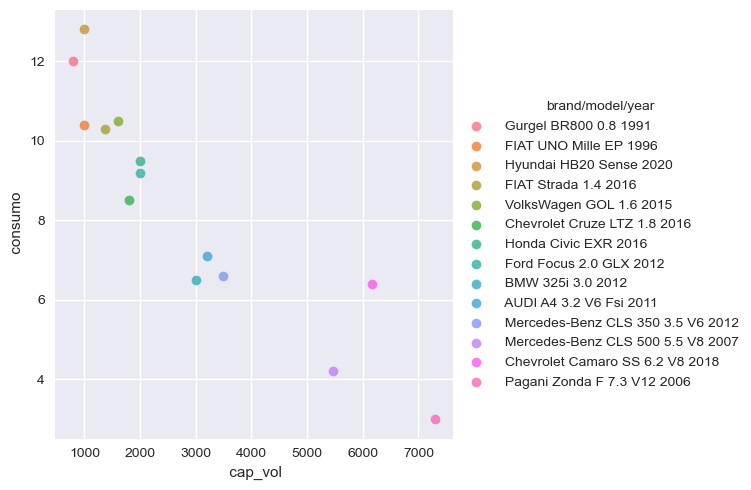

In [144]:
plt.rcParams.update({'figure.figsize':(10,8), 'figure.dpi':100})
sns.lmplot(x=' cap_vol', y=' consumo',hue='brand/model/year', data=df1);

In [145]:
a= modelo.conf_int(alpha=0.05, cols=None) #intervalo de confiança de b0 e b1
a

,0,1
const,10.735300,13.201858
cap_vol,-0.001613,-0.000906


In [146]:
display(a.iloc[0,:]) #intervalo de confiança b0
display(a.iloc[1,:]) #intervalo de confiança b0

0    10.735300
1    13.201858
Name: const, dtype: float64

0   -0.001613
1   -0.000906
Name:  cap_vol, dtype: float64

----

# Semana 7 - Critérios de escolha em modelos de regressão múltipla

A loja "GT Auto" decidiu aprimorar os treinamentos de vendedores inexperientes de carros, criando uma base de dados dos veículos disponíveis que apresente algumas informações importantes para treinar os novos vendedores. A base de dados foi criada em um documento de texto e contém as seguintes informações:

*   Marca/Modelo/Ano do carro: brand/model/year
*   Capacidade volumétrica (cc) ou volume de deslocamento do motor: cap_vol.
*   Consumo de combustível (km/l): consumo.
*   Potência (cv): power.
*   Peso (kg): weight.
*   0-100 (s), tempo que o carro demora para atingir a velocidade de 100km/h: cemm. 
*   Número de cilindros: nu_cy.
*   Tipo de motor, aspirado (0) ou turbo (1): Etype.
 

Após ter realizado a análise dos dados apresentados, obter o modelo de regressão múltipla, escolha as variáveis adequadas.

## Importações

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf #adicionada na semana 6
import seaborn as sns
import scipy.stats as stats #adicionada na semana 6
from scipy.stats import f #adicionada na semana 6
from statsmodels.graphics.gofplots import ProbPlot

In [3]:
cars = pd.read_csv("Fonte_de_dados/carst7.txt", index_col=0)#cars = pd.read_table("carst.txt",sep="\t", header=0, index_col=0)

In [4]:
#Observar os nomes das variáveis
cars.columns

Index(['cap_vol', 'consumo', 'power', 'weight', 'cemm', 'nu_cy', 'Etype'], dtype='str')

In [5]:
#Observar o tipo de dado de cada coluna
print(cars.dtypes)

cap_vol      int64
consumo    float64
power        int64
weight       int64
cemm       float64
nu_cy        int64
Etype        int64
dtype: object


In [6]:
#Observar os índices
print(cars.index)

Index(['Gurgel BR800 0.8 1991', 'FIAT UNO Mille EP 1996',
       'Hyundai HB20 Sense 2020', 'FIAT Strada 1.4 2016',
       'VolksWagen GOL 1.6 2015', 'Chevrolet Cruze LTZ 1.8 2016',
       'Honda Civic EXR 2016', 'Ford Focus 2.0 GLX 2012', 'BMW 325i 3.0 2012',
       'AUDI A4 3.2 V6 Fsi 2011', 'Mercedes-Benz CLS 350 3.5 V6 2012',
       'Mercedes-Benz CLS 500 5.5 V8 2007', 'Chevrolet Camaro SS 6.2 V8 2018',
       'Pagani Zonda F 7.3 V12 2006', 'Volkswagen Polo Highline 1.0 Tsi 2021',
       'Chevrolet Tracker Premier 1.2 T 2021',
       'Chevrolet Cruze LTZ 1.4 T 2021', 'Honda Civic Touring 1.5 T 2021',
       'Peugeot 306 Griffe 1.6 THP 2019', 'Audi A4 Attraction 1.8 TSFi 2015',
       'BMW 320i Sport 2.0 T 2020', 'Porsche Panamera 3.0 V6 2018',
       'Honda NSX 3.5 V6 T 2017', 'Nissan GTR Nismo 3.8 V6 T 2015',
       'Mercedes-Benz E63 S AMG 4.0 V8 2021',
       'Aston Martin DB11 5.2 V12 T 2017', 'Pagani Huayra 6.0 V12 T 2014',
       'Bugatti Chiron 8.0 W16 2016'],
      dtype='s

In [7]:
# Reduzir a base de dados para usar apenas 
# o motor naturalmente aspirado
dfcars = cars.iloc[1:14,:]
dfcars.head(15)

,cap_vol,consumo,power,weight,cemm,nu_cy,Etype
brand_model_year,,,,,,,
FIAT UNO Mille EP 1996,994,10.4,58,870,18.6,4,0
Hyundai HB20 Sense 2020,1000,12.8,80,989,14.5,3,0
FIAT Strada 1.4 2016,1368,10.3,86,1084,12.5,4,0
VolksWagen GOL 1.6 2015,1598,10.5,104,961,9.8,4,0
Chevrolet Cruze LTZ 1.8 2016,1796,8.5,144,1427,10.2,4,0
Honda Civic EXR 2016,1997,9.5,155,1294,10.9,4,0
Ford Focus 2.0 GLX 2012,1999,9.2,148,1347,10.4,4,0
BMW 325i 3.0 2012,2996,6.5,218,1460,7.1,6,0
AUDI A4 3.2 V6 Fsi 2011,3197,7.1,269,1610,6.4,6,0


In [8]:
#dimensões 
print(dfcars.shape) 
#número de instâncias 
na = dfcars.shape[0] 
# número de variáveis
pa = dfcars.shape[1] - 1

(13, 7)


## Regressão Primeira opção

In [9]:

#Regressão com a fórmula import statsmodels.formula.api as smf 
regmul = smf.ols('consumo ~ cap_vol + power + weight', data = dfcars) 
#Realizar o processo de modelagem
res = regmul.fit()

In [10]:
#Membros do objeto reg
print(dir(regmul))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_check_kwargs', '_data_attr', '_df_model', '_df_resid', '_fit_collinear', '_fit_ridge', '_fit_zeros', '_formula_max_endog', '_get_init_kwds', '_handle_data', '_init_keys', '_kwargs_allowed', '_setup_score_hess', '_sqrt_lasso', 'data', 'df_model', 'df_resid', 'endog', 'endog_names', 'exog', 'exog_names', 'fit', 'fit_regularized', 'formula', 'from_formula', 'get_distribution', 'hessian', 'hessian_factor', 'information', 'initialize', 'k_constant', 'loglike', 'nobs', 'normalized_cov_params', 'pinv_wexog', 'predict', 'rank', 'score', 'weights', 'wendog', 'wexog', 'wexog_singular_values', 'wh

In [11]:
#Membros do objeto que o processo de modelagem forneceu
print(dir(res))

['HC0_se', 'HC1_se', 'HC2_se', 'HC3_se', '_HCCM', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abat_diagonal', '_cache', '_data_attr', '_data_in_cache', '_get_robustcov_results', '_get_wald_nonlinear', '_is_nested', '_transform_predict_exog', '_use_t', '_wexog_singular_values', 'aic', 'bic', 'bse', 'centered_tss', 'compare_f_test', 'compare_lm_test', 'compare_lr_test', 'condition_number', 'conf_int', 'conf_int_el', 'cov_HC0', 'cov_HC1', 'cov_HC2', 'cov_HC3', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'eigenvals', 'el_test', 'ess', 'f_pvalue', 'f_test', 'fittedvalues', 'fvalue', 'get_influence', 'get_prediction', 

In [12]:
#Resultado detalhado
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     18.17
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000369
Time:                        18:42:19   Log-Likelihood:                -18.408
No. Observations:                  13   AIC:                             44.82
Df Residuals:                       9   BIC:                             47.08
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8973      1.640      8.475      0.0

## Cálculo do Fcrit (tabela)

In [13]:

import scipy.stats
F=res.fvalue
k=res.df_model # grau do modelo
n=res.nobs # num. amostras
dfn=k
dfd=n-(k+1)
alpha = 0.1 #nível de confiança.
F_critico=scipy.stats.f.ppf(1-alpha, dfn, dfd)
print("F_crit=",F_critico) #tabela F-dist

F_crit= 2.8128629971823895


## Cálculo t_crit (tabela t-student)

In [14]:

from scipy.stats import t
alpha = 0.1  # significia = 5% 
df = 11 # graus de liberdade                                      
v = t.ppf(1 - alpha/2, df) 
tt=v
print(f't_crit=: {v}')

t_crit=: 1.7958848187040433


## Regressão Segunda opção

In [15]:

regmul2 = smf.ols('consumo ~ cap_vol + power + weight + nu_cy', data = dfcars) 
#Realizar o processo de modelagem
res2 = regmul2.fit()
#Resultado detalhado
print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     85.91
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.32e-06
Time:                        18:43:18   Log-Likelihood:                -6.5200
No. Observations:                  13   AIC:                             23.04
Df Residuals:                       8   BIC:                             25.86
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.0213      1.437     15.329      0.0

## Regressão Terceira opção

In [16]:

regmul3 = smf.ols('consumo ~ power + weight + nu_cy', data = dfcars) 
#Realizar o processo de modelagem
res3 = regmul3.fit()
#Resultado detalhado
print(res3.summary())

                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     124.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.19e-07
Time:                        18:43:41   Log-Likelihood:                -6.7184
No. Observations:                  13   AIC:                             21.44
Df Residuals:                       9   BIC:                             23.70
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.9086      1.358     16.132      0.0

In [17]:
res3.params

Intercept    21.908572
power         0.020282
weight       -0.005344
nu_cy        -2.022731
dtype: float64

In [18]:
# Gráficos dispersão e resíduos
#Valores previstos e residuos
y_pred=list(res3.predict())
resi=list(res3.resid)
#crear instancia influence
influence = res3.get_influence()
#obter residuos standardizados
stdresid = list(influence.resid_studentized_internal)
prop=np.divide(resi,stdresid) #e/e*

In [19]:
y=list(dfcars['consumo'])
dftab = pd.DataFrame(list(zip(y,y_pred,resi,stdresid,prop)),
               columns =["y","y_p","e","e*","e/e*"])
dftab.head(10)

,y,y_p,e,e*,e/e*
0,10.4,10.345134,0.054866,0.140443,0.390663
1,12.8,12.178190,0.621810,1.617789,0.384358
2,10.3,9.769516,0.530484,1.217066,0.435871
3,10.5,10.791847,-0.291847,-0.675226,0.432221
4,8.5,9.113044,-0.613044,-1.359483,0.450939
5,9.5,10.046835,-0.546835,-1.228797,0.445017
6,9.2,9.621654,-0.421654,-0.927807,0.454463
7,6.5,6.392115,0.107885,0.272351,0.396125
8,7.1,6.624970,0.475030,1.067406,0.445033
9,6.6,6.707464,-0.107464,-0.252444,0.425695


## Gráficos de diagnóstico 2 (y vs. yc)

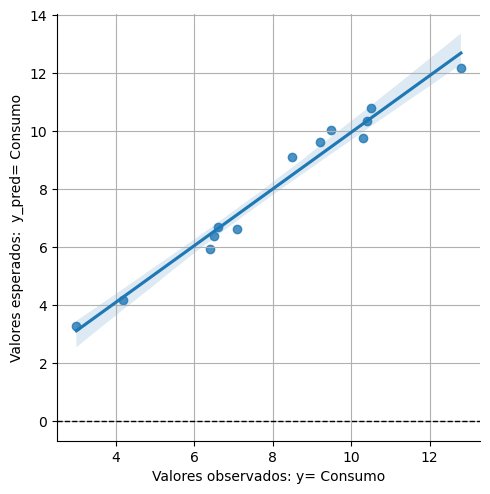

In [20]:
#Gráficos de diagnóstico 2 (y vs. yc)
sns.lmplot(x='y', y='y_p', data=dftab);plt.grid(True)
plt.xlabel('Valores observados: y= Consumo')
plt.ylabel('Valores esperados:  y_pred= Consumo')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

## Gráficos de diagnóstico 3 (resíduos padronizados vs. x)

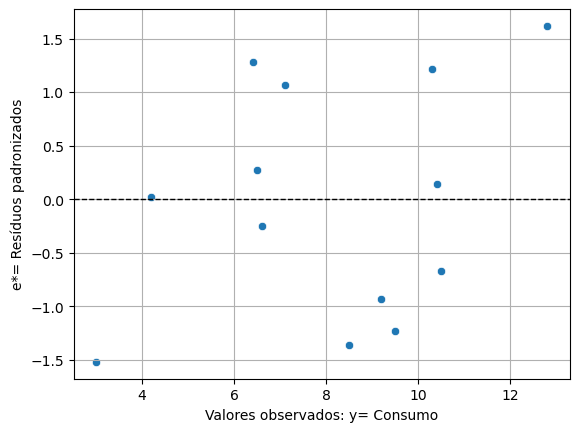

In [21]:

sns.scatterplot(x='y', y='e*', data=dftab);plt.grid(True)
plt.xlabel('Valores observados: y= Consumo')
plt.ylabel('e*= Resíduos padronizados')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.show()

## Gráficos de diagnóstico 4

C:\Users\Amanda Rodrigues\AppData\Roaming\Python\Python313\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


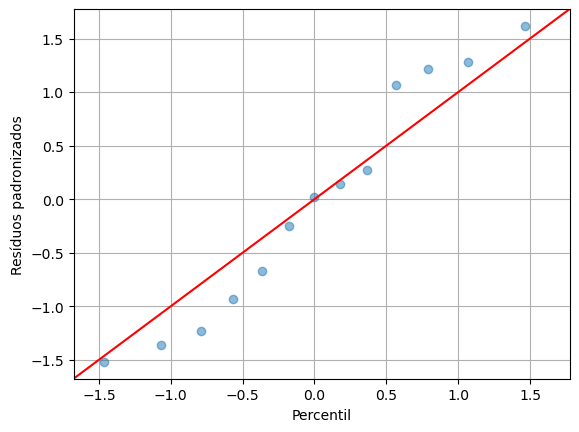

In [22]:

#Verificar a normalidade dos resíduos
#qqpolot vs. normal distribution 
QQ = ProbPlot(influence.resid_studentized_internal)
plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
plot_lm_2.axes[0].set_xlabel('Percentil')
plot_lm_2.axes[0].set_ylabel('Resíduos padronizados')
plt.grid(True)

In [23]:
#Jarque-Bera normality test import statsmodels.api as sm 
JB, JBpv,skw,kurt = sm.stats.stattools.jarque_bera(res3.resid) 
print(JB,JBpv,skw,kurt)

0.9356004195554896 0.6263786554878776 0.08916068550630663 1.6979002335974016


In [24]:
#Analisar amostras influentes
infl = res3.get_influence()
#leverage 
print(infl.hat_matrix_diag)

[0.35806038 0.37861409 0.20088976 0.21422029 0.14468658 0.16700463
 0.13126423 0.33998544 0.16694511 0.23776741 0.32914283 0.46714838
 0.86427087]


In [25]:
#Valores dos resíduos (influencias internas)
#residus = res3.resid.as_matrix() #residuals
leviers = infl.hat_matrix_diag #leverage
sigma_err = np.sqrt(res3.scale) #regression standard error
res_stds = stdresid/(sigma_err*np.sqrt(1.0-leviers))
print(res_stds)

[ 0.35949995  4.20906954  2.79225934 -1.5622264  -3.01478277 -2.7612392
 -2.04154318  0.68753833  2.39848859 -0.59301501  0.05304166  3.59442848
 -8.46147643]


In [26]:
#Limiar 
#threshold leverage
seuil_levier = 2*(pa+1)/na
print(seuil_levier)
#identification
atyp_levier = leviers > seuil_levier
print(atyp_levier)

1.0769230769230769
[False False False False False False False False False False False False
 False]


In [27]:
#Quais carros ultrapassam esse limiar
print(dfcars.index[atyp_levier],leviers[atyp_levier])

Index([], dtype='str', name='brand_model_year') []


In [28]:
#dimensões 
print(dfcars.shape) 
#número de instâncias 
na = dfcars.shape[0] 
# número de variáveis
pa = dfcars.shape[1] - 4
na,pa

(13, 7)


(13, 3)

In [29]:
#valores fornecidos pelo objeto
print(infl.resid_studentized_external)
#verificando com a fórmula
res_studs = res_stds*np.sqrt((na-pa-2)/(na-pa-1-res_stds**2))
print(res_studs)

[ 0.13255651  1.81118385  1.25541191 -0.65337419 -1.43784066 -1.26993869
 -0.91983983  0.25783951  1.07682554 -0.23885329  0.01997201  1.33351375
 -1.66218952]
[ 0.34139992         nan  7.1997264  -1.72526295         nan -6.65900839
 -2.62685161  0.66594194  3.76465014 -0.57035397  0.05001597         nan
         nan]


C:\Users\Amanda Rodrigues\AppData\Local\Temp\ipykernel_24312\4099764749.py:4: RuntimeWarning: invalid value encountered in sqrt
  res_studs = res_stds*np.sqrt((na-pa-2)/(na-pa-1-res_stds**2))


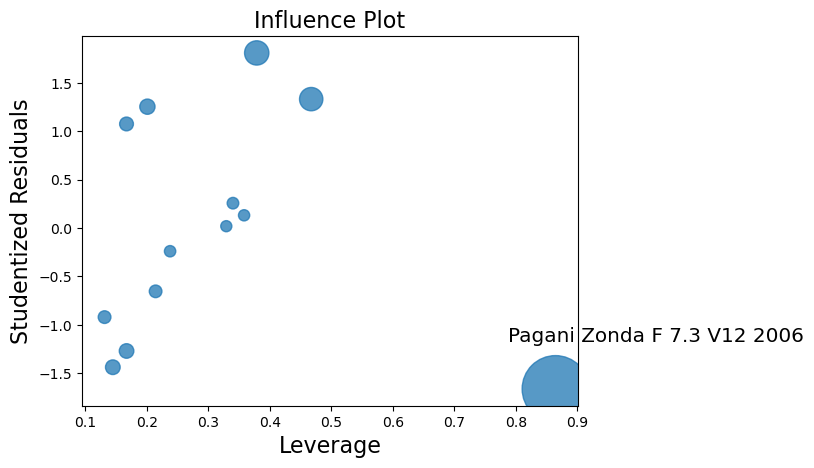

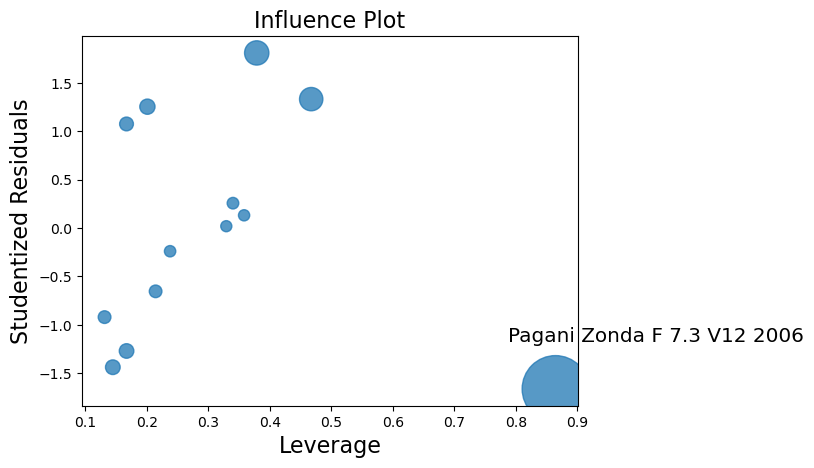

In [30]:
#Representação dos pontos influentes
sm.graphics.influence_plot(res3)

In [32]:
#limiares dos resíduos (influencias externas)
import scipy
seuil_stud = scipy.stats.t.ppf(0.975,df=na-pa-2)
print(seuil_stud)
#detection - absolute value > threshold
atyp_stud = np.abs(res_studs) > seuil_stud
#which ones?
print(dfcars.index[atyp_stud],res_studs[atyp_stud])

2.306004135204166
Index(['FIAT Strada 1.4 2016', 'Honda Civic EXR 2016',
       'Ford Focus 2.0 GLX 2012', 'AUDI A4 3.2 V6 Fsi 2011'],
      dtype='str', name='brand_model_year') [ 7.1997264  -6.65900839 -2.62685161  3.76465014]


In [33]:
#Observações suspeitas considerando ambos critérios
pbm_infl = np.logical_or(atyp_levier,atyp_stud)
print(dfcars.index[pbm_infl])

Index(['FIAT Strada 1.4 2016', 'Honda Civic EXR 2016',
       'Ford Focus 2.0 GLX 2012', 'AUDI A4 3.2 V6 Fsi 2011'],
      dtype='str', name='brand_model_year')


In [34]:
#Outros critérios para determinar amostras influentes
print(infl.summary_frame().filter(["hat_diag","student_resid","dffits","cooks_d"]))

                                   hat_diag  student_resid    dffits   cooks_d
brand_model_year                                                              
FIAT UNO Mille EP 1996             0.358060       0.132557  0.098999  0.002750
Hyundai HB20 Sense 2020            0.378614       1.811184  1.413775  0.398675
FIAT Strada 1.4 2016               0.200890       1.255412  0.629451  0.093093
VolksWagen GOL 1.6 2015            0.214220      -0.653374 -0.341147  0.031074
Chevrolet Cruze LTZ 1.8 2016       0.144687      -1.437841 -0.591374  0.078161
Honda Civic EXR 2016               0.167005      -1.269939 -0.568625  0.075681
Ford Focus 2.0 GLX 2012            0.131264      -0.919840 -0.357554  0.032517
BMW 325i 3.0 2012                  0.339985       0.257840  0.185056  0.009552
AUDI A4 3.2 V6 Fsi 2011            0.166945       1.076826  0.482054  0.057082
Mercedes-Benz CLS 350 3.5 V6 2012  0.237767      -0.238853 -0.133402  0.004970
Mercedes-Benz CLS 500 5.5 V8 2007  0.329143       0.

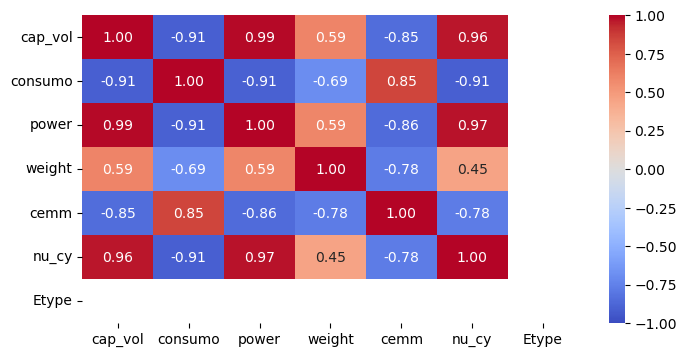

In [35]:
# Calcula a correlação entre os atributos numéricos
corr = dfcars.corr()
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [36]:
infl.exog[:,1:4]

array([[  58.,  870.,    4.],
       [  80.,  989.,    3.],
       [  86., 1084.,    4.],
       [ 104.,  961.,    4.],
       [ 144., 1427.,    4.],
       [ 155., 1294.,    4.],
       [ 148., 1347.,    4.],
       [ 218., 1460.,    6.],
       [ 269., 1610.,    6.],
       [ 306., 1735.,    6.],
       [ 388., 1760.,    8.],
       [ 461., 1709.,    8.],
       [ 602., 1230.,   12.]])

In [42]:
#correlation matrix 
from scipy.stats import pearsonr
import numpy as np
mc = np.corrcoef(infl.exog[:,1:4], rowvar=0) 
print(mc)

[[1.         0.59225355 0.96890823]
 [0.59225355 1.         0.44569531]
 [0.96890823 0.44569531 1.        ]]


In [43]:
#Klein’s rule of thumb 
mc2 = mc**2 
print(mc2)

[[1.         0.35076427 0.93878317]
 [0.35076427 1.         0.19864431]
 [0.93878317 0.19864431 1.        ]]


In [44]:
#VIF criterion 
vif = np.linalg.inv(mc) 
print(vif)

[[ 34.35864218  -6.87792632 -30.22491181]
 [ -6.87792632   2.62471127   5.49425794]
 [-30.22491181   5.49425794  27.83640092]]


## Extras

In [45]:
#ANOVA
table = sm.stats.anova_lm(res, typ=2) # 
print(table)

             sum_sq   df         F    PR(>F)
cap_vol    0.249945  1.0  0.174047  0.686315
power      0.205274  1.0  0.142941  0.714138
weight     3.079927  1.0  2.144682  0.177102
Residual  12.924689  9.0       NaN       NaN


In [46]:
#estimated coefficients 
print(res.params) 
#R2
print(res.rsquared) 
#calculating the F-statistic 
F = res.mse_model/res.mse_resid 
print(F) 
#F provided by the res object 
print(res.fvalue)

Intercept    13.897284
cap_vol      -0.000544
power        -0.006088
weight       -0.002053
dtype: float64
0.8583177713910947
18.17414462953639
18.17414462953639


### Analisando todas as variáveis do modelo final

In [47]:
dfex = dfcars.drop(columns=["Etype",       # nome
                      "cemm",       # nome
                      "cap_vol"])     # nome
dfex.head()

,consumo,power,weight,nu_cy
brand_model_year,,,,
FIAT UNO Mille EP 1996,10.4,58,870,4
Hyundai HB20 Sense 2020,12.8,80,989,3
FIAT Strada 1.4 2016,10.3,86,1084,4
VolksWagen GOL 1.6 2015,10.5,104,961,4
Chevrolet Cruze LTZ 1.8 2016,8.5,144,1427,4


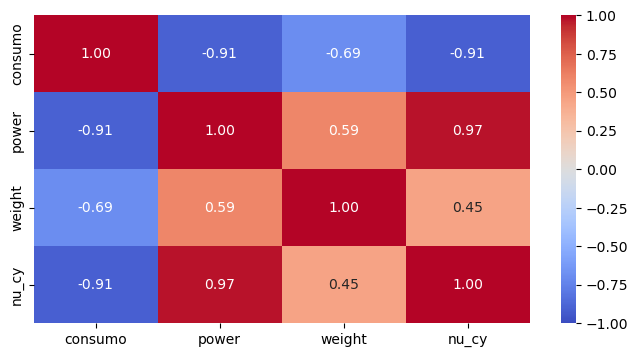

In [48]:
# Calcula a correlação entre os atributos numéricos
corr = dfex.corr()
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [49]:
print(corr)

          consumo     power    weight     nu_cy
consumo  1.000000 -0.905766 -0.687542 -0.913702
power   -0.905766  1.000000  0.592254  0.968908
weight  -0.687542  0.592254  1.000000  0.445695
nu_cy   -0.913702  0.968908  0.445695  1.000000


In [50]:
#Klein’s rule of thumb 
mc2 = corr**2 
print(mc2)

          consumo     power    weight     nu_cy
consumo  1.000000  0.820412  0.472714  0.834851
power    0.820412  1.000000  0.350764  0.938783
weight   0.472714  0.350764  1.000000  0.198644
nu_cy    0.834851  0.938783  0.198644  1.000000


<Axes: >

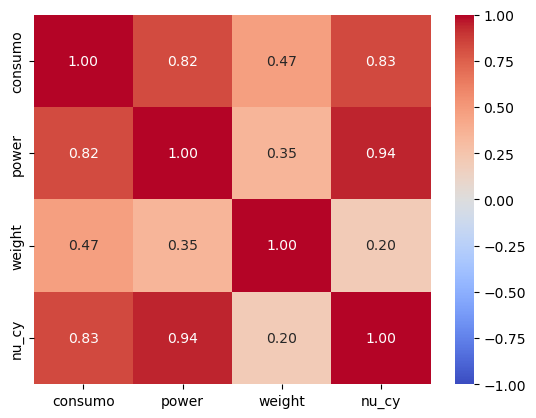

In [51]:
sns.heatmap(mc2, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)

In [52]:
#VIF criterion 
vif = np.linalg.inv(mc2) 
print(vif)

[[  4.94510596   0.86342415  -1.727545    -4.59582941]
 [  0.86342415  11.18956754  -2.18959009 -10.79045883]
 [ -1.727545    -2.18959009   1.96748437   3.10696401]
 [ -4.59582941 -10.79045883   3.10696401  14.34955472]]


<Axes: >

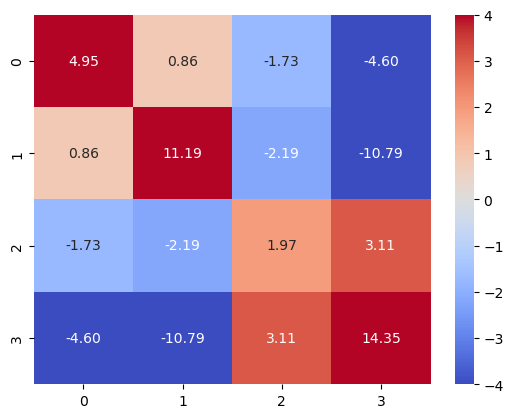

In [53]:
sns.heatmap(vif, cmap='coolwarm', annot=True, fmt=".2f", vmin=-4, vmax=4)

### Analisando apenas as variáveis preditoras do modelo final

In [54]:
dfex1 = dfcars.drop(columns=["Etype",       # nome
                      "cemm",       # nome
                      "consumo",       # nome
                      "cap_vol"])     # nome
dfex1.head()

,power,weight,nu_cy
brand_model_year,,,
FIAT UNO Mille EP 1996,58,870,4
Hyundai HB20 Sense 2020,80,989,3
FIAT Strada 1.4 2016,86,1084,4
VolksWagen GOL 1.6 2015,104,961,4
Chevrolet Cruze LTZ 1.8 2016,144,1427,4


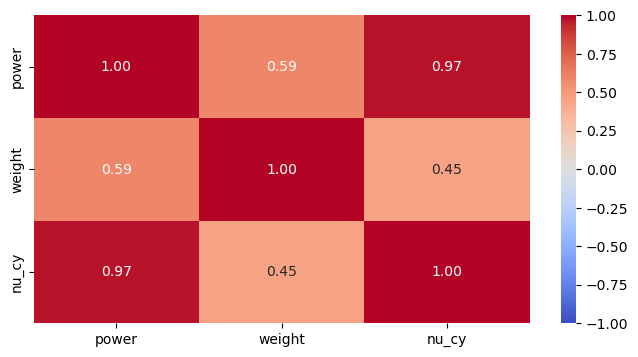

In [55]:
# Calcula a correlação entre os atributos numéricos
corr1 = dfex1.corr()
# Resultado
plt.figure(figsize=(8, 4))
sns.heatmap(corr1, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.show()

In [56]:
print(corr1)

           power    weight     nu_cy
power   1.000000  0.592254  0.968908
weight  0.592254  1.000000  0.445695
nu_cy   0.968908  0.445695  1.000000


In [57]:
#Klein’s rule of thumb 
mc21 = corr1**2 
print(mc21)

           power    weight     nu_cy
power   1.000000  0.350764  0.938783
weight  0.350764  1.000000  0.198644
nu_cy   0.938783  0.198644  1.000000


<Axes: >

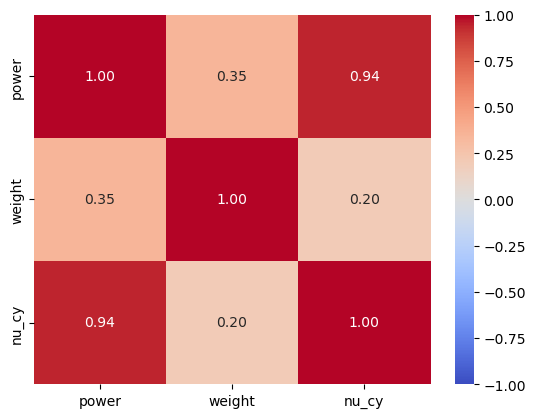

In [58]:
sns.heatmap(mc21, cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)

In [59]:
#VIF criterion 
vif1 = np.linalg.inv(mc21) 
print(vif1)

[[11.03881217 -1.88795771 -9.98801898]
 [-1.88795771  1.36397622  1.5014368 ]
 [-9.98801898  1.5014368  10.07833219]]


<Axes: >

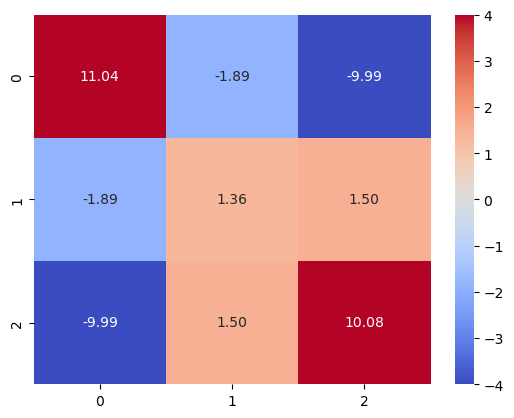

In [60]:
sns.heatmap(vif1, cmap='coolwarm', annot=True, fmt=".2f", vmin=-4, vmax=4)